# Bilevel Planning in KinDER

See the [bilevel-planning README](../../bilevel-planning/README.md) for background on bilevel planning. This notebook demonstrates how to use it in a KinDER environment.

In [1]:
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from PIL import Image as PILImage

import kinder
from bilevel_planning.abstract_plan_generators.heuristic_search_plan_generator import (
    RelationalHeuristicSearchAbstractPlanGenerator,
)
from bilevel_planning.bilevel_planners.sesame_planner import SesamePlanner
from bilevel_planning.structs import PlanningProblem
from bilevel_planning.trajectory_samplers.parameterized_controller_sampler import (
    ParameterizedControllerTrajectorySampler,
)
from bilevel_planning.utils import (
    RelationalAbstractSuccessorGenerator,
    RelationalControllerGenerator,
)
from kinder_bilevel_planning.agent import BilevelPlanningAgent
from kinder_bilevel_planning.env_models import create_bilevel_planning_models

## Setting Up the Environment

We use **Obstruction2D** with one obstruction — the robot must relocate the
obstacle before it can place the target block on the goal surface.

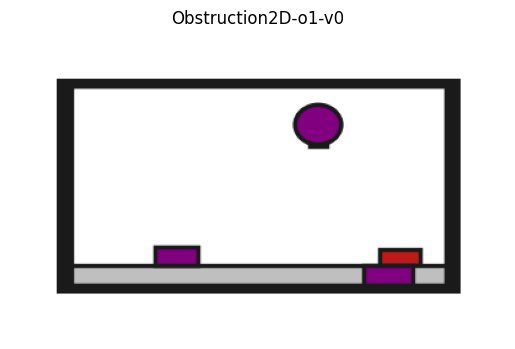

In [2]:
kinder.register_all_environments()

env = kinder.make("kinder/Obstruction2D-o1-v0", render_mode="rgb_array")
obs, info = env.reset(seed=123)

frame = env.render()
plt.imshow(frame)
plt.axis("off")
plt.title("Obstruction2D-o1-v0")
plt.show()

## Bilevel Planning Models

In [3]:
env_models = create_bilevel_planning_models(
    "obstruction2d",
    env.observation_space,
    env.action_space,
    num_obstructions=1,
)

## Predicates

Notice that no predicate is sufficient for determining whether an obstruction needs to be moved out of the way, which depends on geometry.

In [4]:
for predicate in sorted(env_models.predicates, key=str):
    print(predicate)

(HandEmpty ?x0 - crv_robot)
(Holding ?x0 - crv_robot ?x1 - rectangle)
(OnTable ?x0 - rectangle)
(OnTarget ?x0 - rectangle)


## Operators

In [5]:
for operator in sorted(env_models.operators, key=lambda o: o.name):
    print(operator)
    print()

(:action PickFromTable
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (HandEmpty ?robot)
        (OnTable ?block))
    :effect (and (Holding ?robot ?block)
        (not (HandEmpty ?robot))
        (not (OnTable ?block)))
)

(:action PickFromTarget
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (HandEmpty ?robot)
        (OnTarget ?block))
    :effect (and (Holding ?robot ?block)
        (not (HandEmpty ?robot))
        (not (OnTarget ?block)))
)

(:action PlaceOnTable
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (Holding ?robot ?block))
    :effect (and (HandEmpty ?robot)
        (OnTable ?block)
        (not (Holding ?robot ?block)))
)

(:action PlaceOnTarget
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (Holding ?robot ?block))
    :effect (and (HandEmpty ?robot)
        (OnTarget ?block)
        (not (Holding ?robot ?block)))
)



## Skills

In [6]:
for skill in sorted(env_models.skills, key=lambda s: s.operator.name):
    ctrl = skill.controller
    print(f"{skill.operator.name:20s} -> {ctrl.name:20s} params: {ctrl.params_space}")

PickFromTable        -> PickController       params: Box(0.0, 1.0, (1,), float32)
PickFromTarget       -> PickController       params: Box(0.0, 1.0, (1,), float32)
PlaceOnTable         -> PlaceOnTableController params: Box(0.0, 1.0, (1,), float32)
PlaceOnTarget        -> PlaceOnTargetController params: Box(0.0, 1.0, (1,), float32)


## Running the Planner

In [7]:
seed = 123
obs, info = env.reset(seed=seed)

initial_state = env_models.observation_to_state(obs)
goal = env_models.goal_deriver(initial_state)

problem = PlanningProblem(
    env_models.state_space,
    env_models.action_space,
    initial_state,
    env_models.transition_fn,
    goal,
)

trajectory_sampler = ParameterizedControllerTrajectorySampler(
    controller_generator=RelationalControllerGenerator(env_models.skills),
    transition_function=env_models.transition_fn,
    state_abstractor=env_models.state_abstractor,
    max_trajectory_steps=100,
)

abstract_plan_generator = RelationalHeuristicSearchAbstractPlanGenerator(
    env_models.types,
    env_models.predicates,
    env_models.operators,
    "hff",
    seed=seed,
)

abstract_successor_fn = RelationalAbstractSuccessorGenerator(env_models.operators)

planner = SesamePlanner(
    abstract_plan_generator,
    trajectory_sampler,
    max_abstract_plans=10,
    num_sampling_attempts_per_step=1,
    abstract_successor_function=abstract_successor_fn,
    state_abstractor=env_models.state_abstractor,
    seed=seed,
)

plan, _ = planner.run(problem, timeout=30.0)
print(f"Plan found with {len(plan.actions)} actions")

Plan found with 130 actions


## Executing the Plan

Done in 129 steps, total reward: -128.00


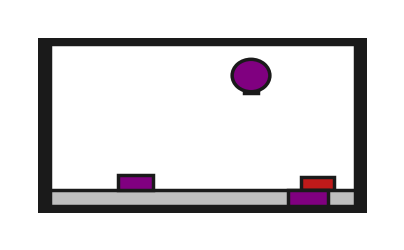

In [8]:
obs, info = env.reset(seed=seed)
frames = [env.render()]
total_reward = 0.0

for action in plan.actions:
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    frames.append(env.render())
    if terminated or truncated:
        break

print(f"Done in {len(frames)} steps, total reward: {total_reward:.2f}")

pil_frames = [PILImage.fromarray(f) for f in frames]
buf = BytesIO()
pil_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,
    loop=0,
)
Image(data=buf.getvalue(), format="gif")

## Using BilevelPlanningAgent

`BilevelPlanningAgent` wraps the planner construction above into a single agent interface. Call `reset()` with an observation to trigger planning, then `step()` to get actions one at a time.

Done in 129 steps, total reward: -128.00


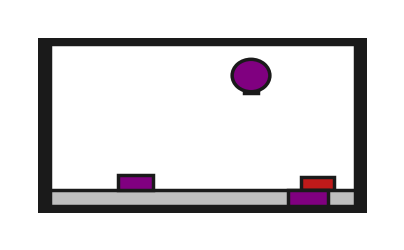

In [9]:
agent = BilevelPlanningAgent(
    env_models,
    seed=seed,
    max_abstract_plans=10,
    samples_per_step=1,
)

obs, info = env.reset(seed=seed)
agent.reset(obs, info)

frames = [env.render()]
total_reward = 0.0

for _ in range(1000):
    action = agent.step()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    agent.update(obs, reward, terminated or truncated, info)
    frames.append(env.render())
    if terminated or truncated:
        break

print(f"Done in {len(frames)} steps, total reward: {total_reward:.2f}")

pil_frames = [PILImage.fromarray(f) for f in frames]
buf = BytesIO()
pil_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,
    loop=0,
)
Image(data=buf.getvalue(), format="gif")

## Cleanup

In [10]:
env.close()